In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from keras import layers, models
from model_trainer import ModelTrainer
from keras.models import load_model # type: ignore
from scipy.signal import savgol_filter

from datagen import DataGen

All data shape (28527999,) (28527999,)
(37, 128) (37, 1)


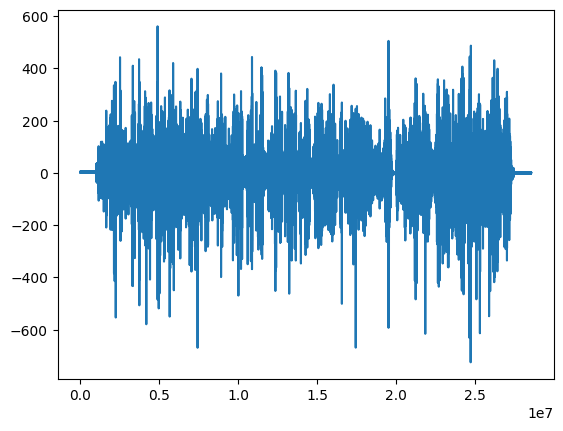

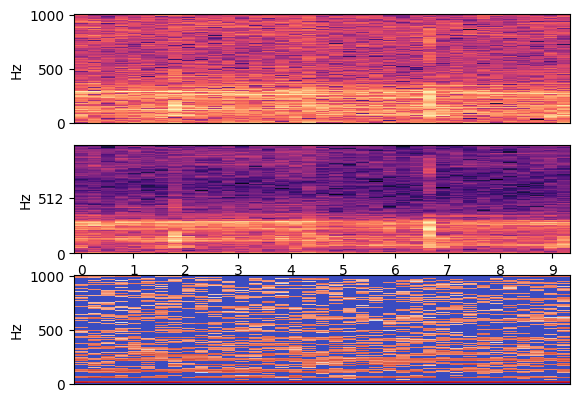

In [ ]:
# X_train = np.load('data\\X_train_1_2.npy')
# X_train = X_train.T
# y_train = np.load('data\\y_train_1_2.npy')
# y_train = y_train.reshape((-1, 1))
# print(X_train.shape, y_train.shape)

X_train_path = r'data\20180920_205115_DBX1.npy'
y_train_path = r'data\20180920_205115_mway.npy'

X_train = np.load(X_train_path)
y_train = np.load(y_train_path)

generator = DataGen(X_train, y_train, smpl_r=2000, batch_size=18000)

X, y = generator.__getitem__(100, plot_mode=False)
print(X.shape, y.shape)
del X, y


In [3]:
model_name = f'Akselerometers_gen_Velaro_bs_{generator.batch_size}'

model = models.Sequential(
    [
        layers.Input(shape=(128,)),

        layers.Reshape((128, 1)),
        layers.Conv1D(filters=8, kernel_size=3, padding='same'),
        layers.Activation(activation='tanh'),
        layers.Conv1D(filters=4, kernel_size=2, padding='same'),
        # layers.BatchNormalization(),
        layers.Activation(activation='tanh'),
        layers.Flatten(),
        layers.Dense(32, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='linear')
    ]
)

model.compile(loss='mse', optimizer='adam', metrics=['mse'])
model.name = model_name
model.summary()

Model: "Akselerometers_gen_Velaro_bs_18000"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 128, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 8)         │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 4)         │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,077 (105.77 KB)

 Trainable params: 27,077 (105.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
m_trainer = ModelTrainer(model=model, data_ref=[X_train_path, y_train_path])
m_trainer.train(X_train=generator, y_train=None, epochs=500, patience=150)

In [ ]:
import pandas as pd
data = pd.read_csv(os.path.join(m_trainer.session_path, 'training_log.csv'), sep=";")
val_mse_values = data['mse']
epochs = data['epoch']
plt.title('val_mse')
plt.plot(epochs, val_mse_values, linestyle='-', color='b')

In [ ]:
# model = load_model(r"D:\Projects\Буксов_аксл\models\Akselerometers_mel128\20260209_1817\Akselerometers_mel128.keras"
#                    )

In [ ]:
X_test = np.load('data\\X_train_128.npy').astype(np.float32)
y_test = np.load('data\\y_train_128.npy').astype(np.float32)
X_test = X_test.T
y_test = y_test.reshape((-1))

print('X_test', X_test.shape, 'y_test', y_test.shape)


plt.figure(figsize=(12, 4))
y_pred = model.predict(X_test)
y_pred_f = savgol_filter(y_pred.reshape((-1)), window_length=200, polyorder=4)
plt.plot(y_test[80:], color='b', label='y_true')
plt.plot(y_pred_f[80:], color='r', label='y_pred_f')
plt.legend()


In [ ]:
# loss

from keras.losses import mean_squared_error # type: ignore
loss = mean_squared_error(y_test[200:], y_pred_f[200:])
print('MSE', np.mean(loss))

loss = np.sqrt((np.mean(np.square(y_test[200:] - y_pred_f[200:]))))
print('RMSE', loss)